# Injera Benchmark Analysis
Load a `benchmark_results.json` file and explore the data interactively.

In [23]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RESULTS_FILE = 'benchmark_6p_1000g_checkpoint_latest_20260303_183925_s.json'

with open(RESULTS_FILE) as f:
    data = json.load(f)

config = data['config']
print(f"Games: {config['games']}  Players: {config['players']}  Deterministic: {config['deterministic']}")
print(f"Special cards: {config['special_cards']}")
for i, ck in enumerate(config['checkpoints']):
    print(f"  Player {i}: {Path(ck).name}")

Games: 1000  Players: 6  Deterministic: False
Special cards: 1
  Player 0: checkpoint_latest.pt
  Player 1: checkpoint_latest.pt
  Player 2: checkpoint_latest.pt
  Player 3: checkpoint_latest.pt
  Player 4: checkpoint_latest.pt
  Player 5: checkpoint_latest.pt


In [24]:
# --- Flatten game data into a per-player DataFrame ---
rows = []
for game in data['games']:
    for ps in game['players']:
        row = {
            'game': game['game'],
            'turns': game['turns'],
            'truncated': game['truncated'],
            'player_idx': ps['player_idx'],
            'checkpoint': Path(ps['checkpoint']).name,
            'rank': ps['rank'],
            'won': ps['rank'] == 1,
            'final_score': ps['final_score'],
            'special_card_bonus': ps['special_card_bonus'],
            'variety_bonus': ps['variety_bonus'],
            'tahini_consumed': ps['tahini_consumed'],
            'drink_cards_played': ps['drink_cards_played'],
            'rotate_cards_played': ps['rotate_cards_played'],
            'tahini_cards_played': ps['tahini_cards_played'],
            'completion_bonuses': len(ps['completion_bonuses']),
        }
        # Cards dealt
        for card, cnt in ps.get('cards_dealt', {}).items():
            row[f'dealt_{card}'] = cnt
        # Drink tokens
        for dtype, cnt in ps.get('drink_tokens_consumed', {}).items():
            row[f'tokens_{dtype}'] = cnt
        # Dishes eaten
        for dish, cnt in ps.get('dishes_eaten', {}).items():
            row[f'dish_{dish}'] = cnt
        rows.append(row)

df = pd.DataFrame(rows).fillna(0)
print(f"Rows: {len(df)}  Columns: {len(df.columns)}")
df.head()

Rows: 6000  Columns: 34


,game,turns,truncated,player_idx,checkpoint,rank,won,final_score,special_card_bonus,variety_bonus,...,dish_Berbere Misir,dish_Kik Alicha,dealt_Beer,dealt_TAHINI,tokens_Beer,dish_Gomen,dealt_Water,tokens_Water,dealt_Coffee,tokens_Coffee
0,1,176,False,0,checkpoint_latest.pt,5,False,19,0,8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,176,False,1,checkpoint_latest.pt,6,False,15,0,10,...,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,176,False,2,checkpoint_latest.pt,2,False,41,0,10,...,1.0,2.0,2.0,1.0,6.0,2.0,0.0,0.0,0.0,0.0
3,1,176,False,3,checkpoint_latest.pt,1,True,42,0,10,...,1.0,2.0,1.0,0.0,3.0,2.0,1.0,3.0,0.0,0.0
4,1,176,False,4,checkpoint_latest.pt,4,False,23,0,8,...,1.0,1.0,0.0,0.0,0.0,2.0,1.0,3.0,1.0,3.0


## Win Rates

,games,wins,win_rate,avg_score,avg_rank
player_idx,,,,,
0,1000,220,0.220,29.194,2.988
1,1000,195,0.195,28.923,3.079
2,1000,182,0.182,28.519,3.210
3,1000,199,0.199,28.388,3.229
4,1000,140,0.140,27.386,3.419
5,1000,137,0.137,26.691,3.537


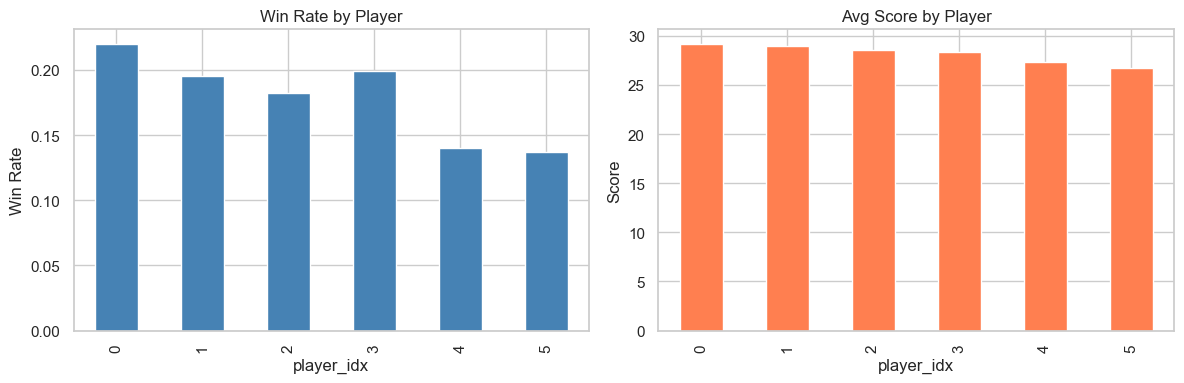

In [25]:
# Win rate and avg score by player index
by_player = df.groupby('player_idx').agg(
    games=('game', 'count'),
    wins=('won', 'sum'),
    win_rate=('won', 'mean'),
    avg_score=('final_score', 'mean'),
    avg_rank=('rank', 'mean'),
).round(3)
display(by_player)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_player['win_rate'].plot.bar(ax=axes[0], title='Win Rate by Player', color='steelblue')
axes[0].set_ylabel('Win Rate')
by_player['avg_score'].plot.bar(ax=axes[1], title='Avg Score by Player', color='coral')
axes[1].set_ylabel('Score')
plt.tight_layout()

In [50]:
# Win rate by checkpoint (useful when comparing different checkpoints)
by_ck = df.groupby('checkpoint').agg(
    appearances=('game', 'count'),
    win_rate=('won', 'mean'),
    avg_score=('final_score', 'mean'),
    avg_rank=('rank', 'mean'),
).round(3)
display(by_ck)

,appearances,win_rate,avg_score,avg_rank
checkpoint,,,,
checkpoint_episode_90600.pt,1000,0.473,98.961,1.527
checkpoint_latest.pt,1000,0.540,100.724,1.460


## Score Distribution

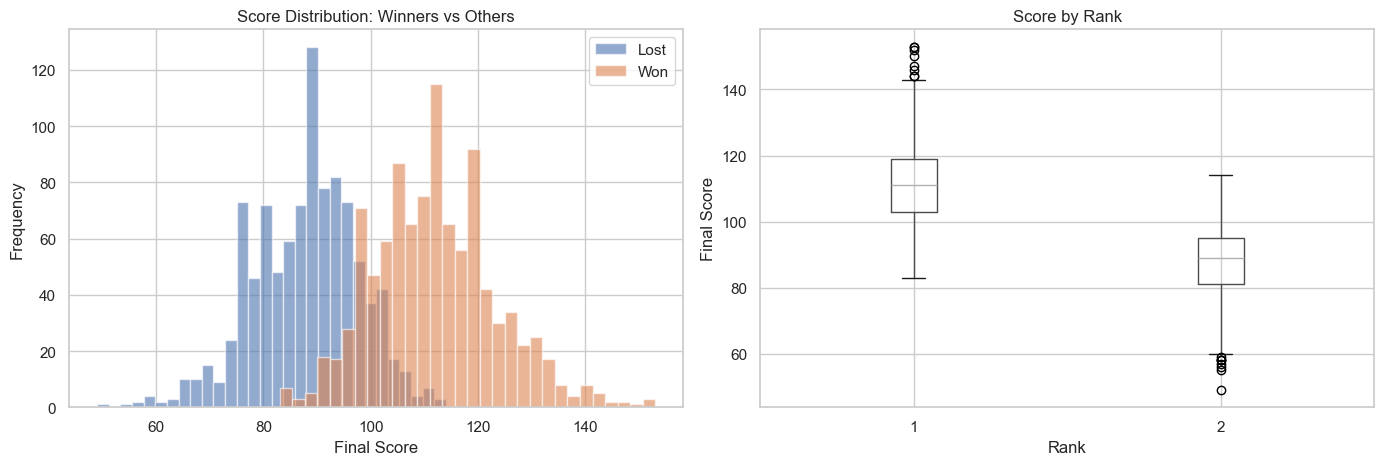

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution by winner vs loser
df.groupby('won')['final_score'].plot.hist(bins=30, alpha=0.6, ax=axes[0], legend=True)
axes[0].set_title('Score Distribution: Winners vs Others')
axes[0].set_xlabel('Final Score')
axes[0].legend(['Lost', 'Won'])

# Score by rank
df.boxplot(column='final_score', by='rank', ax=axes[1])
axes[1].set_title('Score by Rank')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Final Score')
plt.suptitle('')
plt.tight_layout()

## Cards: Correlation with Winning

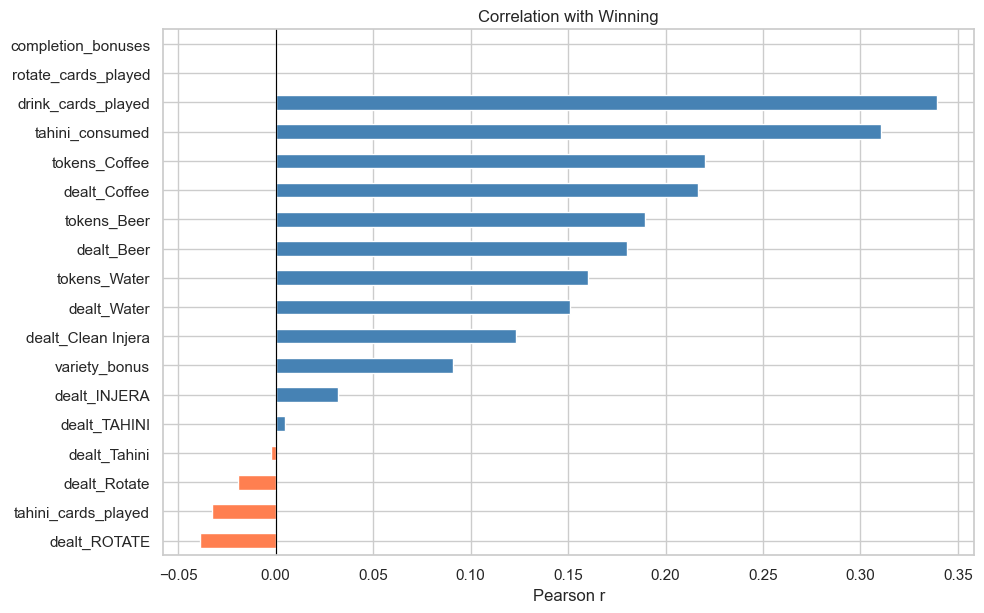

In [26]:
# Correlation of card-related columns with winning
card_cols = [c for c in df.columns if c.startswith('dealt_') or c.startswith('tokens_')
             or c in ('drink_cards_played', 'rotate_cards_played', 'tahini_cards_played',
                      'tahini_consumed', 'variety_bonus', 'completion_bonuses')]

corr = df[card_cols + ['won']].corr()['won'].drop('won').sort_values()

fig, ax = plt.subplots(figsize=(10, max(4, len(corr) * 0.35)))
colors = ['coral' if v < 0 else 'steelblue' for v in corr]
corr.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation with Winning')
ax.set_xlabel('Pearson r')
plt.tight_layout()

In [22]:
# Average values: winners vs non-winners
comparison = df.groupby('won')[card_cols].mean().T.round(2)
comparison.columns = ['Lost', 'Won']
comparison['diff'] = (comparison['Won'] - comparison['Lost']).round(2)
comparison['diff_%'] = ((comparison['Won'] / comparison['Lost'].replace(0, np.nan) - 1) * 100).round(1)
display(comparison.sort_values('diff', ascending=False))

,Lost,Won,diff,diff_%
tahini_consumed,7.62,11.50,3.88,50.9
tokens_Beer,1.25,2.63,1.38,110.4
tokens_Coffee,1.25,2.61,1.36,108.8
drink_cards_played,1.28,2.48,1.20,93.8
tokens_Water,1.34,2.21,0.87,64.9
dealt_Clean Injera,6.64,7.26,0.62,9.3
variety_bonus,8.09,8.61,0.52,6.4
dealt_Beer,0.47,0.97,0.50,106.4
dealt_Coffee,0.44,0.91,0.47,106.8
dealt_Water,0.47,0.77,0.30,63.8


## Drink Analysis

=== Avg drink tokens consumed per game ===


won,Lost,Won
tokens_Coffee,2.60,6.35
tokens_Water,3.92,5.06
tokens_Beer,2.69,3.89


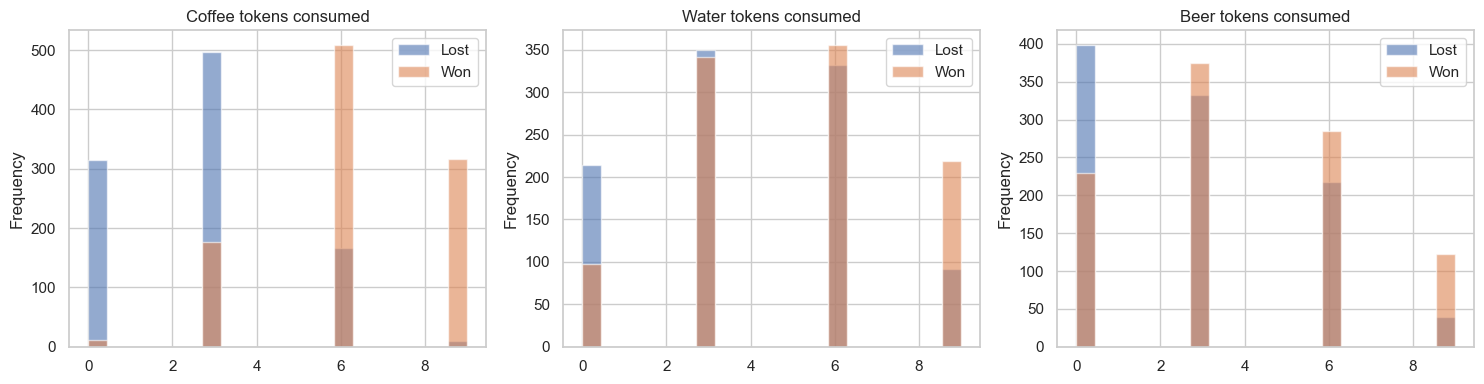

In [21]:
drink_cols = [c for c in df.columns if c.startswith('tokens_')]
deal_drink_cols = [c for c in df.columns if c.startswith('dealt_') and
                   any(d in c for d in ['Coffee', 'Beer', 'Water'])]

print('=== Avg drink tokens consumed per game ===')
display(df.groupby('won')[drink_cols].mean().T.round(2).rename(columns={False: 'Lost', True: 'Won'}))

fig, axes = plt.subplots(1, len(drink_cols), figsize=(5 * len(drink_cols), 4))
if len(drink_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, drink_cols):
    df.groupby('won')[col].plot.hist(bins=20, alpha=0.6, ax=ax, legend=True)
    ax.set_title(col.replace('tokens_', '') + ' tokens consumed')
    ax.legend(['Lost', 'Won'])
plt.tight_layout()

## Dish Analysis

,Lost,Won,diff
Berbere Misir,2.92,3.92,1.00
Azifa,3.09,3.81,0.72
Tikel Gomen,3.17,3.71,0.54
Shiro,3.26,3.73,0.47
Misir Wot,3.44,3.56,0.12
Kik Alicha,3.50,3.23,-0.27
Gomen,3.74,3.27,-0.47


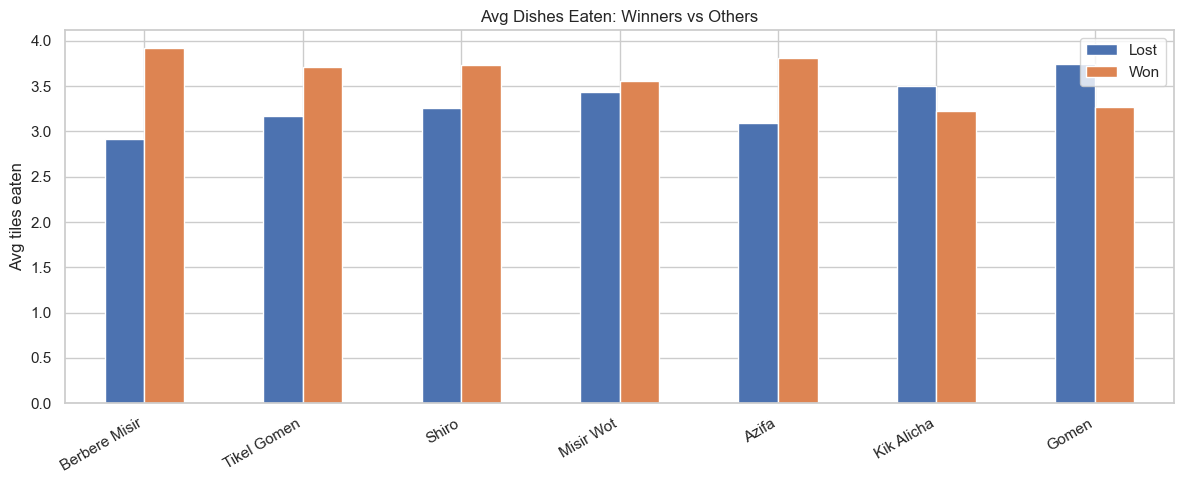

In [22]:
dish_cols = [c for c in df.columns if c.startswith('dish_')]
dish_names = [c.replace('dish_', '') for c in dish_cols]

# Average dishes eaten: winners vs losers
dish_comparison = df.groupby('won')[dish_cols].mean().T.round(2)
dish_comparison.columns = ['Lost', 'Won']
dish_comparison.index = dish_names
dish_comparison['diff'] = (dish_comparison['Won'] - dish_comparison['Lost']).round(2)
display(dish_comparison.sort_values('diff', ascending=False))

dish_comparison[['Lost', 'Won']].plot.bar(figsize=(12, 5), title='Avg Dishes Eaten: Winners vs Others')
plt.ylabel('Avg tiles eaten')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

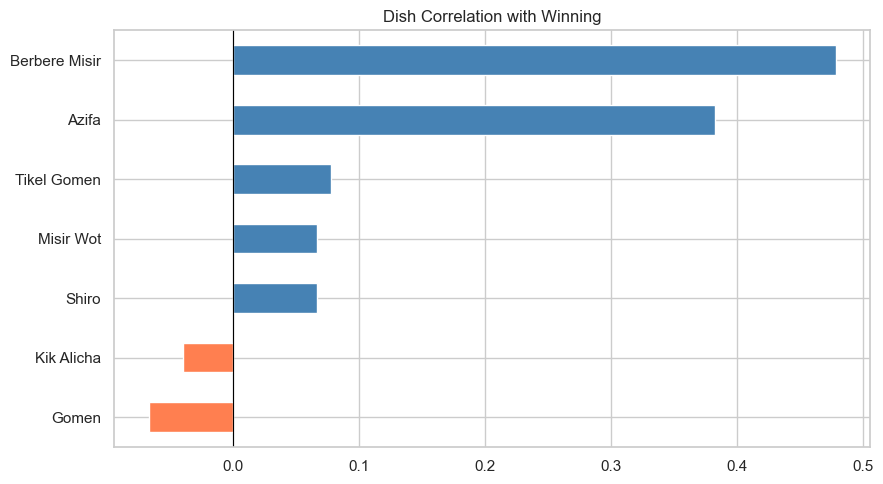

In [23]:
# Dish correlation with winning
dish_corr = df[dish_cols + ['won']].corr()['won'].drop('won')
dish_corr.index = dish_names
dish_corr = dish_corr.sort_values()

colors = ['coral' if v < 0 else 'steelblue' for v in dish_corr]
dish_corr.plot.barh(color=colors, figsize=(9, 5), title='Dish Correlation with Winning')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()

## Tahini & Rotate

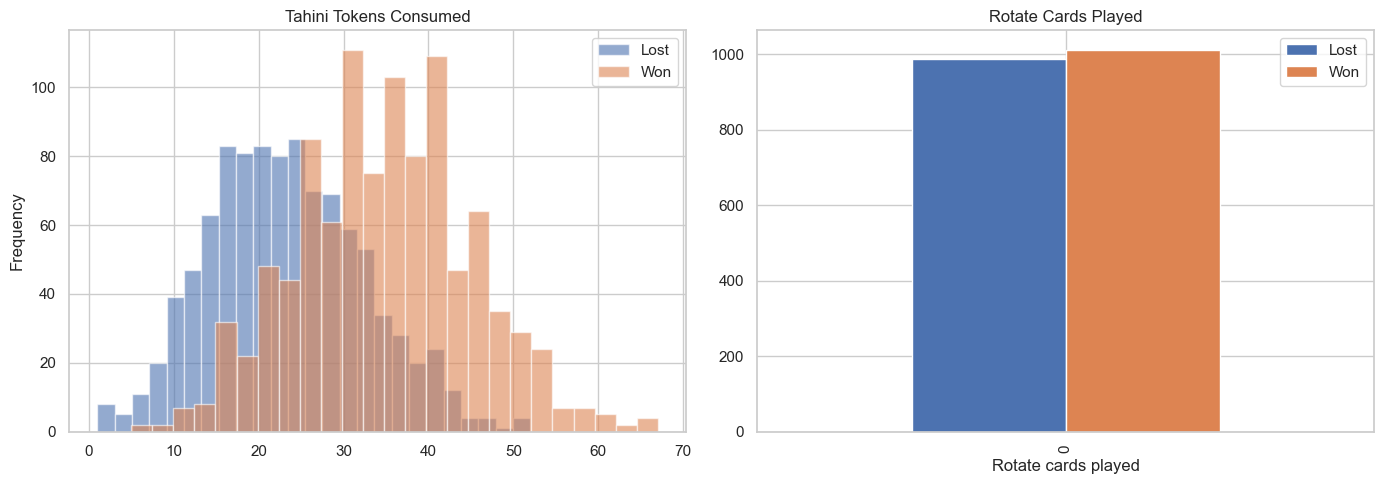

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('won')['tahini_consumed'].plot.hist(bins=25, alpha=0.6, ax=axes[0], legend=True)
axes[0].set_title('Tahini Tokens Consumed')
axes[0].legend(['Lost', 'Won'])

df.groupby('won')['rotate_cards_played'].value_counts().unstack(0).fillna(0).plot.bar(
    ax=axes[1], title='Rotate Cards Played')
axes[1].set_xlabel('Rotate cards played')
axes[1].legend(['Lost', 'Won'])
plt.tight_layout()

In [12]:
print('=== Avg tahini consumed: winners vs losers ===')
display(df.groupby('won')['tahini_consumed'].describe().round(2).T)

print('\n=== Rotate cards played: winners vs losers ===')
display(df.groupby('won')['rotate_cards_played'].describe().round(2).T)

=== Avg tahini consumed: winners vs losers ===


won,False,True
count,4957.00,1043.00
mean,10.34,18.47
std,5.35,7.03
min,0.00,1.00
25%,6.00,14.00
50%,10.00,18.00
75%,14.00,23.00
max,36.00,51.00



=== Rotate cards played: winners vs losers ===


won,False,True
count,4957.0,1043.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


## Bonuses

=== Avg bonuses: winners vs losers ===


won,Lost,Won
variety_bonus,9.98,10.0
completion_bonuses,1.00,1.0
special_card_bonus,0.00,0.0


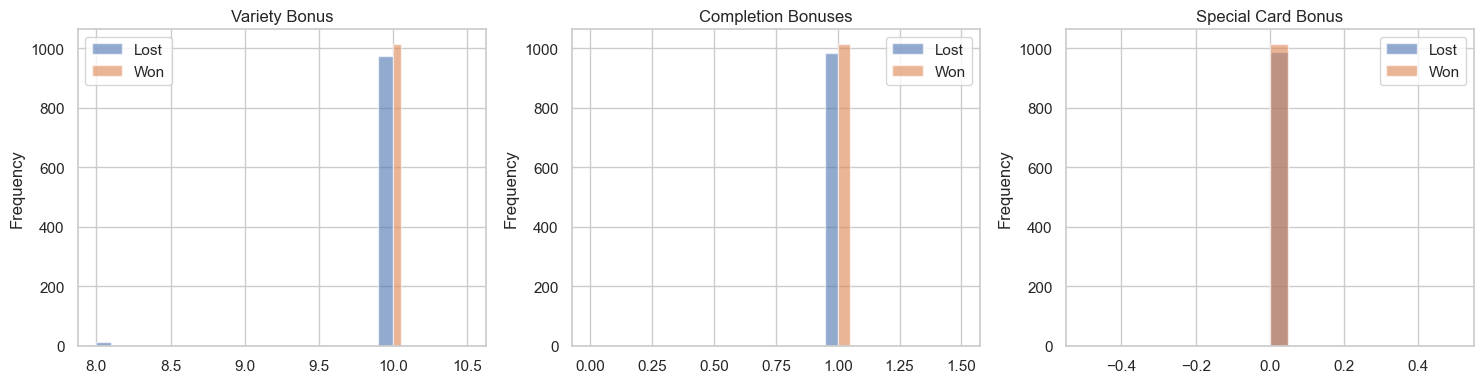

In [25]:
bonus_cols = ['variety_bonus', 'completion_bonuses', 'special_card_bonus']
bonus_cols = [c for c in bonus_cols if c in df.columns]

print('=== Avg bonuses: winners vs losers ===')
display(df.groupby('won')[bonus_cols].mean().T.round(2).rename(columns={False: 'Lost', True: 'Won'}))

fig, axes = plt.subplots(1, len(bonus_cols), figsize=(5 * len(bonus_cols), 4))
if len(bonus_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, bonus_cols):
    df.groupby('won')[col].plot.hist(bins=20, alpha=0.6, ax=ax, legend=True)
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(['Lost', 'Won'])
plt.tight_layout()

## Special Cards

,card,appearances,win_rate,avg_score,avg_bonus,avg_rank
idx,,,,,,
5,picky_eater,348,0.270,30.138,3.621,2.989
6,some_like_it_hot,337,0.249,30.142,3.522,2.760
3,tahini_queen,324,0.225,27.877,1.451,3.265
1,tahini_freak,331,0.224,30.172,3.689,2.924
8,berbere_freak,337,0.193,28.445,2.065,3.202
4,tasting_menu,331,0.184,28.245,1.571,3.166
10,peas_please,310,0.184,28.890,2.410,3.135
0,four_by_four,312,0.179,29.131,3.115,3.074
17,consolation_prize,323,0.173,28.204,2.043,3.266


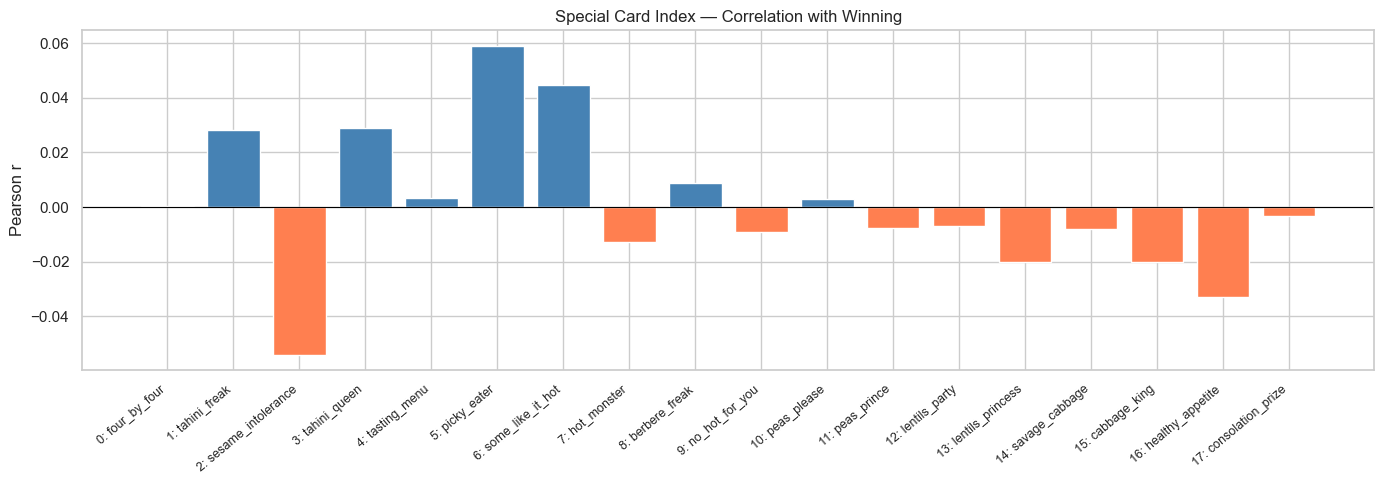

In [27]:
ALL_SPECIAL_CARDS = [
    'four_by_four', 'tahini_freak', 'sesame_intolerance', 'tahini_queen',
    'tasting_menu', 'picky_eater', 'some_like_it_hot', 'hot_monster',
    'berbere_freak', 'no_hot_for_you', 'peas_please', 'peas_prince',
    'lentils_party', 'lentils_princess', 'savage_cabbage', 'cabbage_king',
    'healthy_appetite', 'consolation_prize',
]

# Build per-player rows with one-hot special card columns
sc_rows = []
for game in data['games']:
    for ps in game['players']:
        row = {'game': game['game'], 'player_idx': ps['player_idx'],
               'won': ps['rank'] == 1, 'rank': ps['rank'],
               'final_score': ps['final_score'],
               'special_card_bonus': ps['special_card_bonus']}
        held = ps.get('special_cards_received', [])
        for idx, card in enumerate(ALL_SPECIAL_CARDS):
            row[f'sc_{idx}'] = int(card in held)
        sc_rows.append(row)

sc_df = pd.DataFrame(sc_rows)
sc_cols = [f'sc_{i}' for i in range(18)]
present = [c for c in sc_cols if sc_df[c].sum() > 0]

if not present:
    print("No special cards in this benchmark file.")
    print("Re-run with --special-cards 1 (now the default).")
else:
    # --- Correlation of card index with winning ---
    corr_by_idx = sc_df[present + ['won']].corr()['won'].drop('won')
    indices = [int(c.split('_')[1]) for c in corr_by_idx.index]
    labels = [f"{i}: {ALL_SPECIAL_CARDS[i]}" for i in indices]

    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ['coral' if v < 0 else 'steelblue' for v in corr_by_idx.values]
    ax.bar(range(len(indices)), corr_by_idx.values, color=colors)
    ax.set_xticks(range(len(indices)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=9)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Special Card Index — Correlation with Winning')
    ax.set_ylabel('Pearson r')
    plt.tight_layout()

    # --- Win rate & avg bonus table ---
    sc_stats = []
    for col in present:
        idx = int(col.split('_')[1])
        subset = sc_df[sc_df[col] == 1]
        sc_stats.append({
            'idx': idx,
            'card': ALL_SPECIAL_CARDS[idx],
            'appearances': len(subset),
            'win_rate': subset['won'].mean(),
            'avg_score': subset['final_score'].mean(),
            'avg_bonus': subset['special_card_bonus'].mean(),
            'avg_rank': subset['rank'].mean(),
        })
    sc_stats_df = pd.DataFrame(sc_stats).set_index('idx').sort_values('win_rate', ascending=False).round(3)
    display(sc_stats_df)

## Full Correlation Heatmap

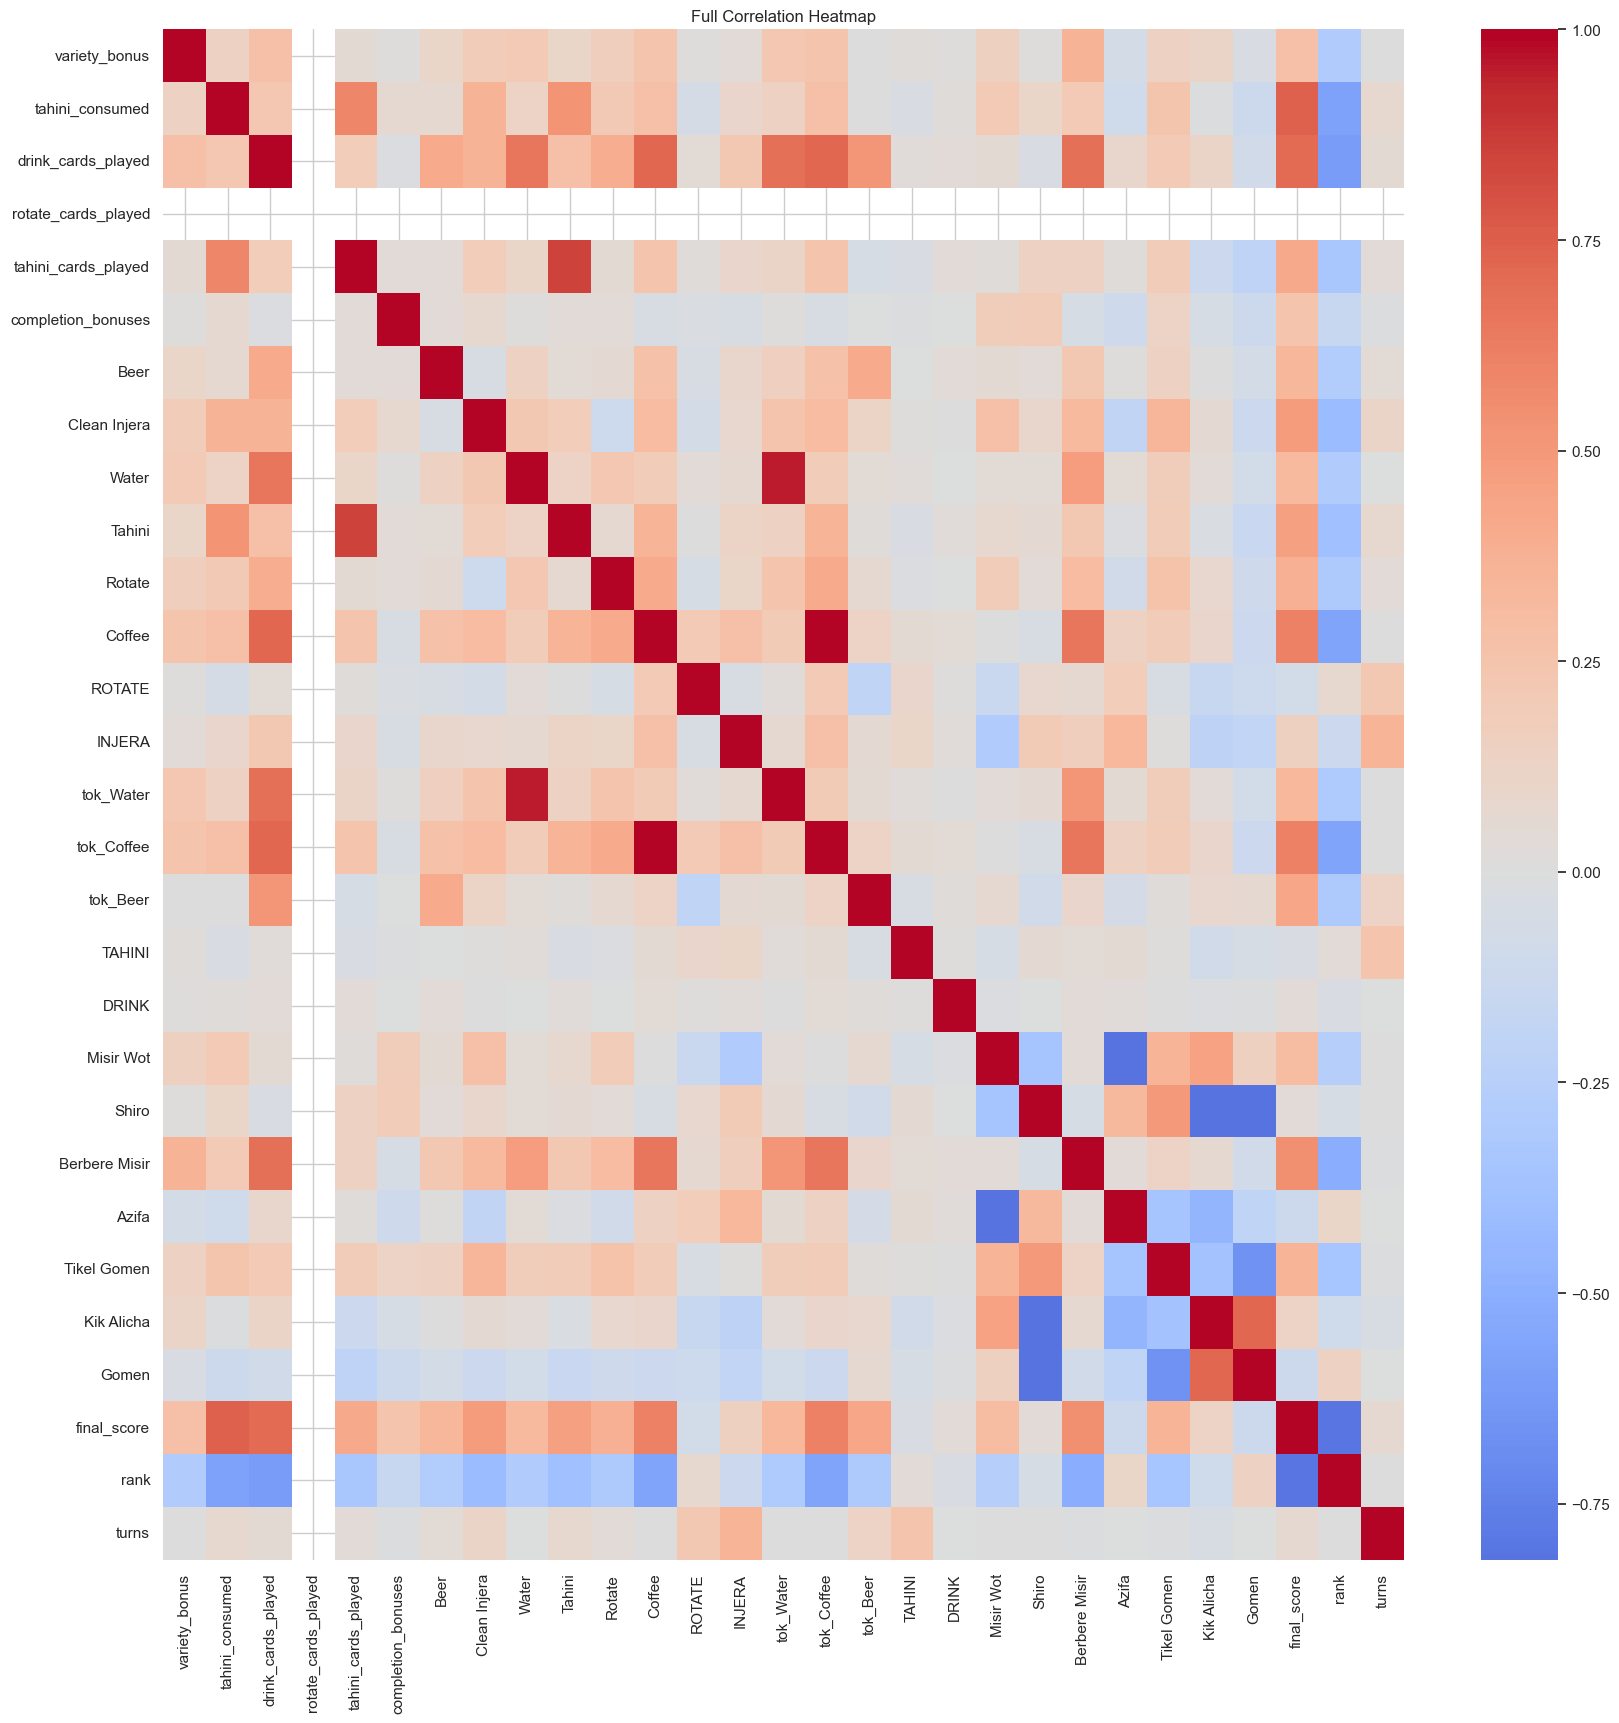

In [14]:
numeric_cols = card_cols + dish_cols + ['final_score', 'rank', 'turns']
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(max(12, len(numeric_cols) * 0.6), max(10, len(numeric_cols) * 0.6)))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            xticklabels=[c.replace('dish_', '').replace('dealt_', '').replace('tokens_', 'tok_') for c in numeric_cols],
            yticklabels=[c.replace('dish_', '').replace('dealt_', '').replace('tokens_', 'tok_') for c in numeric_cols],
            ax=ax)
ax.set_title('Full Correlation Heatmap')
plt.tight_layout()

## Custom Query
Use `df` directly — one row per player per game.

In [ ]:
# Example: how often does the player with the most tahini consumed win?
game_groups = df.groupby('game')
most_tahini_wins = 0
total = 0
for _, g in game_groups:
    if len(g) < 2:
        continue
    best = g.loc[g['tahini_consumed'].idxmax()]
    most_tahini_wins += int(best['won'])
    total += 1
print(f"Player with most tahini consumed wins {most_tahini_wins}/{total} games ({100*most_tahini_wins/total:.1f}%)")

In [ ]:
# Example: does playing more drink cards correlate with winning?
print(df.groupby('won')[['drink_cards_played', 'tahini_cards_played', 'rotate_cards_played']].mean().round(3))

In [ ]:
# Your custom query here — df columns:
print(sorted(df.columns.tolist()))